In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

#import numpy as np # linear algebra
#import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Imports

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.models import EfficientNet_B7_Weights
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
import os
import random

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Load Dataset

In [6]:
#dataset_path
#train
#validation
#test

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define dataset directories
data_dir = "/kaggle/input/ibean-aug"
train_dir = f"{data_dir}/augmented_train"
val_dir = f"{data_dir}/augmented_validation"
test_dir = "/kaggle/input/ibeans-test-set/test"

# Define transformations
transform = transforms.Compose([
    transforms.Resize((500, 500)),  # Resize for EfficientNet-B7
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Standard normalization
])

# Load datasets
train_dataset = ImageFolder(root=train_dir, transform=transform)
val_dataset = ImageFolder(root=val_dir, transform=transform)
test_dataset = ImageFolder(root=test_dir, transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# EDA

In [7]:
len(train_dataset.classes)

3

# Model building

In [8]:
#EfficientNET-CNN

In [9]:
# Load EfficientNet with pre-trained weights
model = models.efficientnet_b7(weights=EfficientNet_B7_Weights.IMAGENET1K_V1)

# Freeze base model layers
for param in model.features.parameters():
    param.requires_grad = False

# Modify classifier: Add custom dense layers
#num_ftrs = model.classifier[1].in_features
#model.classifier = nn.Sequential( # Works for EfficientNet-B0
model.fc = nn.Sequential(
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(2560, 1024), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 256), nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, len(train_dataset.classes))  # Output layer
)

# Move model to GPU if available
model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b7_lukemelas-c5b4e57e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b7_lukemelas-c5b4e57e.pth
100%|██████████| 255M/255M [00:01<00:00, 202MB/s] 


In [7]:
#EfficientNET-LSTM

In [13]:
class EfficientNetWithLSTM(nn.Module):
    def __init__(self, num_classes, hidden_dim=256, lstm_layers=4, dropout=0.3):
        super(EfficientNetWithLSTM, self).__init__()
        self.base_model = models.efficientnet_b7(weights=EfficientNet_B7_Weights.IMAGENET1K_V1)
        
        # Freeze EfficientNet layers
        for param in self.base_model.features.parameters():
            param.requires_grad = False

        # Adaptive pooling to reduce spatial dimensions
        self.pool = nn.AdaptiveAvgPool2d((1, None))  # Collapse height to 1, keep width
        self.lstm = nn.LSTM(input_size=2560, 
                            hidden_size=hidden_dim, 
                            num_layers=lstm_layers, 
                            batch_first=True, 
                            dropout=dropout if lstm_layers > 1 else 0)
        self.layer_norm = nn.LayerNorm(hidden_dim)

        self.classifier = nn.Linear(hidden_dim, num_classes)
        

    def forward(self, x):
        x = self.base_model.features(x)  # Shape: (B, 2560, H, W)
        x = self.pool(x)                 # Shape: (B, 2560, 1, W)
        x = x.squeeze(2)                 # Shape: (B, 2560, W)
        x = x.permute(0, 2, 1)           # Shape: (B, W, 2560) for LSTM

        lstm_out, _ = self.lstm(x)       # Shape: (B, W, hidden_dim)
        x = lstm_out[:, -1, :]           # Last time step
        x = self.layer_norm(x)              # Apply LayerNorm before classification
        x = self.classifier(x)
        return x

In [14]:
num_classes = len(train_dataset.classes)
model = EfficientNetWithLSTM(num_classes=num_classes).to(device)

In [10]:
# Criterion and Optimizer
# ----- Run for each model (CNN and LSTM) ----

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4)  # Train only classifier
#optimizer = optim.Adam(model.classifier.parameters(), lr=5e-5)  # Train only classifier (works for EfficientNET-B0)


**CNN Training Loop**

> Updated Training Loop with Efficient + Safe Checkpointing and Early Stopping

In [14]:
# Updated CNN Training Loop with Efficient + Safe Checkpointing and Early Stopping

def train_model(
    model, train_loader, val_loader, criterion, optimizer,
    epochs=20, checkpoint_dir='checkpoints',
    resume=True, patience=5, min_delta=0.01, save_best_every=3
):
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(checkpoint_dir, 'last_checkpoint.pth')
    best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')

    start_epoch = 0
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_val_loss_updated = False

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    # Resume training if checkpoint exists
    if resume and os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        print(f"Resumed training from epoch {start_epoch}")

    for epoch in range(start_epoch, epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        val_acc, val_loss = validate_model(model, val_loader, criterion)

        train_losses.append(running_loss / len(train_loader))
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Loss: {running_loss/len(train_loader):.4f}, "
              f"Train Acc: {train_acc:.2f}%, "
              f"Val Loss: {val_loss:.4f}, "
              f"Val Acc: {val_acc:.2f}%")

        # Best model & Early Stopping logic
        if val_loss < best_val_loss: #- min_delta:
            best_val_loss = val_loss
            best_val_loss_updated = True
            epochs_no_improve = 0 # reset the early stopping flag since learning improved
            print(f"  Validation loss improved by > {min_delta}")
        else:
            best_val_loss_updated = False  # Reset the flag
            epochs_no_improve += 1 # increment early-stopping flag since learning does not improve

        #if (epoch + 1) % save_best_every == 0 and best_val_loss_updated:
         #   torch.save(model.state_dict(), best_model_path)
          #  print(f"  Best model saved at epoch {epoch+1}")
           # best_val_loss_updated = False  # Reset the flag

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
            }, checkpoint_path)
            print(f"  Checkpoint saved at epoch {epoch+1}")

        # Early stopping logic
        #if best_val_loss_updated:
            #best_val_loss = val_loss
         #   epochs_no_improve = 0 # reset if there’s improvement 
          #  print("Learning improved!")
        #else:
         #   epochs_no_improve += 1
          #  print(f"Learning Not improved! Best val_loss={best_val_loss}, Curr val_loss={val_loss}")
            

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            # Final save on early stop
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
            }, checkpoint_path)
            break

    # Save final checkpoint if loop ends naturally
    if epochs_no_improve < patience:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
        }, checkpoint_path)
        print(f"Training finished at epoch {epoch+1}. Final checkpoint saved.")

    # Plot curves
    plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)

def validate_model(model, val_loader, criterion):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = 100 * correct / total
    return val_acc, running_loss / len(val_loader)


def test_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Compute classification report
    class_names = train_dataset.classes
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print("\nClassification Report:\n", report)

In [10]:
# Training, validation and test functions (for CNN Model): No early Stopping. No Checkpointing

# 🔹 **Training, Validation, and Test Functions**
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        val_acc, val_loss = validate_model(model, val_loader, criterion)

        train_losses.append(running_loss / len(train_loader))
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}: Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    # Plot Accuracy and Loss
    plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)


def validate_model(model, val_loader, criterion):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = 100 * correct / total
    return val_acc, running_loss / len(val_loader)


def test_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Compute classification report
    class_names = train_dataset.classes
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print("\nClassification Report:\n", report)

**LSTM Training Loop**

In [16]:
# Training, validation and test functions (for LSTM Model)

# 🔹 **Training, Validation, and Test Functions**
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10,
                patience=3, grad_clip=1.0):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_acc = 0.0
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            # Apply gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        val_acc, val_loss = validate_model(model, val_loader, criterion)

        train_losses.append(running_loss / len(train_loader))
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}: Loss: {running_loss/len(train_loader):.4f}, "
              f"Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

        # Check for improvement
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}. Best Val Acc: {best_val_acc:.2f}%")
                break

    # Restore best model state
    if best_model_state:
        model.load_state_dict(best_model_state)

    # Plot training curves
    plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)


def validate_model(model, val_loader, criterion):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = 100 * correct / total
    return val_acc, running_loss / len(val_loader)


def test_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Compute classification report
    class_names = train_dataset.classes
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print("\nClassification Report:\n", report)

# Training and Evaluation

In [15]:
# Function to plot training curves
# 🔹 **Plot Training Curves**
def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    
    # Loss plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curve')

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy')
    plt.plot(epochs, val_accuracies, label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.title('Accuracy Curve')

    plt.show()

Epoch 1/50: Loss: 1.7117, Train Acc: 75.66%, Val Loss: 0.6078, Val Acc: 91.92%
  Validation loss improved by > 0.01
Epoch 2/50: Loss: 0.4477, Train Acc: 89.90%, Val Loss: 0.3180, Val Acc: 93.72%
  Validation loss improved by > 0.01
Epoch 3/50: Loss: 0.3165, Train Acc: 91.04%, Val Loss: 0.2471, Val Acc: 93.63%
  Validation loss improved by > 0.01
Epoch 4/50: Loss: 0.2697, Train Acc: 91.76%, Val Loss: 0.2095, Val Acc: 94.25%
  Validation loss improved by > 0.01
Epoch 5/50: Loss: 0.2360, Train Acc: 92.24%, Val Loss: 0.1882, Val Acc: 94.21%
  Validation loss improved by > 0.01
Epoch 6/50: Loss: 0.2239, Train Acc: 92.33%, Val Loss: 0.1707, Val Acc: 94.40%
  Validation loss improved by > 0.01
Epoch 7/50: Loss: 0.2090, Train Acc: 92.65%, Val Loss: 0.1623, Val Acc: 94.49%
  Validation loss improved by > 0.01
Epoch 8/50: Loss: 0.2031, Train Acc: 92.64%, Val Loss: 0.1496, Val Acc: 94.94%
  Validation loss improved by > 0.01
Epoch 9/50: Loss: 0.1979, Train Acc: 92.80%, Val Loss: 0.1484, Val Acc: 

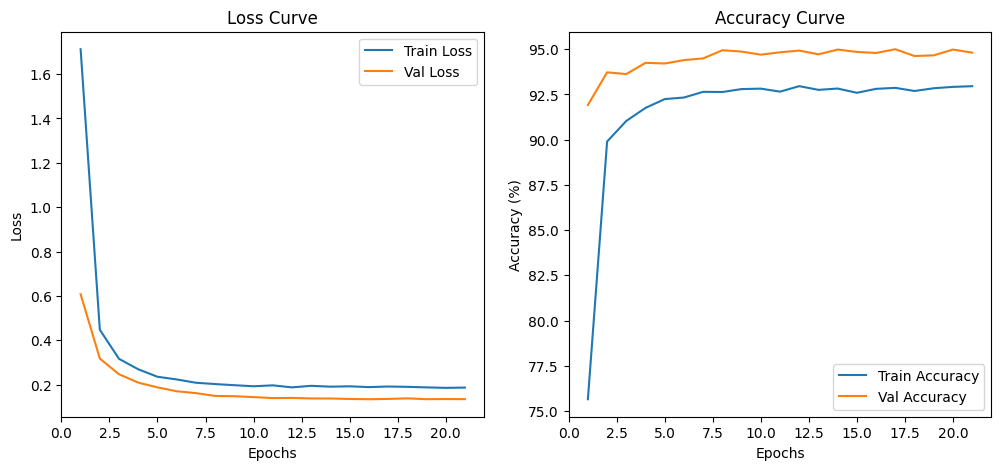

In [16]:
# Train, validate, and test the model
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50)

In [18]:
test_model(model, test_loader)


Classification Report:
                    precision    recall  f1-score   support

angular_leaf_spot     0.8723    0.9535    0.9111        43
        bean_rust     0.9500    0.8837    0.9157        43
          healthy     1.0000    0.9762    0.9880        42

         accuracy                         0.9375       128
        macro avg     0.9408    0.9378    0.9382       128
     weighted avg     0.9403    0.9375    0.9379       128



Epoch 1: Loss: 3.4719, Train Acc: 47.59%, Val Acc: 69.92%
Epoch 2: Loss: 1.7295, Train Acc: 74.91%, Val Acc: 80.53%
Epoch 3: Loss: 1.2422, Train Acc: 79.85%, Val Acc: 84.21%
Epoch 4: Loss: 0.9882, Train Acc: 81.64%, Val Acc: 85.26%
Epoch 5: Loss: 0.8653, Train Acc: 82.68%, Val Acc: 85.79%
Epoch 6: Loss: 0.8170, Train Acc: 82.54%, Val Acc: 86.02%
Epoch 7: Loss: 0.7168, Train Acc: 83.29%, Val Acc: 85.34%
Epoch 8: Loss: 0.6758, Train Acc: 83.61%, Val Acc: 84.81%
Epoch 9: Loss: 0.6446, Train Acc: 83.48%, Val Acc: 85.49%
Epoch 10: Loss: 0.6220, Train Acc: 83.54%, Val Acc: 85.71%


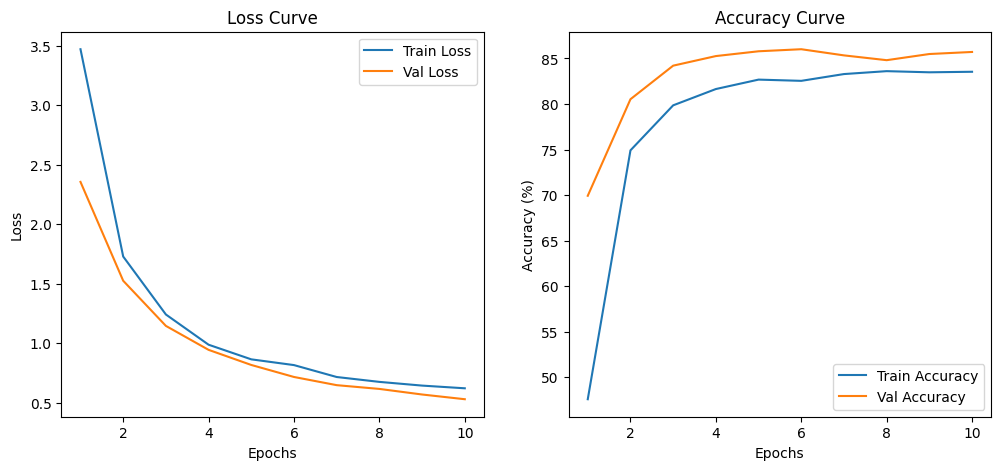

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained EfficientNet-B7
efficientnet = models.efficientnet_b7(weights=models.EfficientNet_B7_Weights.IMAGENET1K_V1)

# Freeze feature extractor layers
for param in efficientnet.features.parameters():
    param.requires_grad = False

# Define custom classifier using Sequential
num_classes = 3  # Adjust based on dataset
classifier = nn.Sequential(
    nn.AdaptiveAvgPool2d(1),  # Global Average Pooling
    nn.Flatten(start_dim=1),  # Flatten layer
    nn.Linear(2560, 1024),  # EfficientNet-B7 has 2560 output channels
    nn.ReLU(),
    nn.Dropout(0.5),  # Dropout (50%)
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.3),  # Dropout (30%)
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, num_classes)  # Final classification layer
)

# Replace EfficientNet classifier with our custom classifier
efficientnet.fc = classifier
model = efficientnet.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Define data transformations
transform = transforms.Compose([
    transforms.Resize((600, 600)),  # Resize for EfficientNet-B7
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
'''train_dataset = datasets.ImageFolder(root="dataset/train", transform=transform)
val_dataset = datasets.ImageFolder(root="dataset/validation", transform=transform)
test_dataset = datasets.ImageFolder(root="dataset/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)'''


# 🔹 **Training, Validation, and Test Functions**
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        val_acc, val_loss = validate_model(model, val_loader, criterion)

        train_losses.append(running_loss / len(train_loader))
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}: Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    # Plot Accuracy and Loss
    plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)


def validate_model(model, val_loader, criterion):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = 100 * correct / total
    return val_acc, running_loss / len(val_loader)


def test_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Compute classification report
    class_names = train_dataset.classes
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print("\nClassification Report:\n", report)


# 🔹 **Plot Training Curves**
def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    
    # Loss plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curve')

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy')
    plt.plot(epochs, val_accuracies, label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.title('Accuracy Curve')

    plt.show()


# 🔹 **Run Training and Evaluation**
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)
#test_model(model, test_loader)


True